# Знакомство с `torch.Tensor`

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann
* https://pytorch.org/docs/stable/torch.html


In [1]:
import torch
import numpy as np
import time
import matplotlib.pyplot as plt

## Задачи для совместного разбора

1\. Создайте тензор и исследуйте его основные характеристики

2\. Создайте трехмерный тензор и рассмотрите основные способы индексирования по нему

3\. Создайте тензор (4х4) и модифицируйте следующим образом: ко всем четным столбцам прибавьте 1, из нечетных вычтите 1.

4\. Обсудите совместимость `torch` с `numpy` и `sklearn`

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Создайте двумерный тензор размера (100000, 10), заполненный нулями. Используя прихотливое индексирование, поставьте в каждой строке тензора ровно одну единицу в случайно выбранном столбце. Рассчитайте и выведите на экран вероятности $p_i$ того, что для случайно выбранной строки в столбце $i$ будет стоять единица.

- [ ] Проверено на семинаре

In [2]:
min_sh, max_sh = 10, 100000

In [3]:
x = torch.zeros(max_sh, min_sh)
x, x.shape

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 torch.Size([100000, 10]))

In [4]:
r_cols = torch.randint(0, min_sh, (max_sh, ))
r_cols, r_cols.shape

(tensor([7, 1, 3,  ..., 3, 0, 7]), torch.Size([100000]))

In [5]:
rows = torch.arange(max_sh)

In [6]:
[rows, r_cols]

[tensor([    0,     1,     2,  ..., 99997, 99998, 99999]),
 tensor([7, 1, 3,  ..., 3, 0, 7])]

In [7]:
x[rows, r_cols] = 1.0
x

tensor([[0., 0., 0.,  ..., 1., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 1., 0., 0.]])

In [8]:
p = x.mean(dim=0).round(decimals=3)
p

tensor([0.1000, 0.1000, 0.0990, 0.1020, 0.1010, 0.1000, 0.1000, 0.1000, 0.1010,
        0.0980])

In [9]:
for i, ps in enumerate(p):
  print(f'вероятности того, что для случайновыбранной строки в i-ом столбце будет 1 равна:\n Столбец {i} - {ps.round(decimals=3)}')

вероятности того, что для случайновыбранной строки в i-ом столбце будет 1 равна:
 Столбец 0 - 0.10000000149011612
вероятности того, что для случайновыбранной строки в i-ом столбце будет 1 равна:
 Столбец 1 - 0.10000000149011612
вероятности того, что для случайновыбранной строки в i-ом столбце будет 1 равна:
 Столбец 2 - 0.0989999994635582
вероятности того, что для случайновыбранной строки в i-ом столбце будет 1 равна:
 Столбец 3 - 0.10199999809265137
вероятности того, что для случайновыбранной строки в i-ом столбце будет 1 равна:
 Столбец 4 - 0.10100000351667404
вероятности того, что для случайновыбранной строки в i-ом столбце будет 1 равна:
 Столбец 5 - 0.10000000149011612
вероятности того, что для случайновыбранной строки в i-ом столбце будет 1 равна:
 Столбец 6 - 0.10000000149011612
вероятности того, что для случайновыбранной строки в i-ом столбце будет 1 равна:
 Столбец 7 - 0.10000000149011612
вероятности того, что для случайновыбранной строки в i-ом столбце будет 1 равна:
 Столбец

<p class="task" id="2"></p>

2\. При помощи прихотливого индексирования для двумерного тензора размерности (10, 10), состоящего из случайных целых чисел в пределах от 0 до 10, получите тензор элементов, находящихся сразу над  побочной диагональю.

- [ ] Проверено на семинаре

In [10]:
min_sh2, max_sh2 = 10, 10 #размерность тензора

In [11]:
x2 = torch.randint(0, 11, (min_sh2, max_sh2)) #инициализация тензора установленной размерности с рандомными числами от 0 до 10
x2

tensor([[ 2,  2,  2,  6,  4,  7,  2,  4,  3,  6],
        [ 1, 10,  2,  0,  6,  3, 10,  7,  9,  3],
        [ 9,  4,  0,  5,  6,  3,  3,  6,  4,  5],
        [ 1,  2, 10,  7,  9,  9,  2,  5,  4,  3],
        [10,  7,  2,  8,  0,  6,  3,  8,  0,  8],
        [ 0,  4,  8,  2, 10,  7,  7, 10,  6,  1],
        [ 9,  1,  1,  5,  4, 10,  5,  8,  6,  0],
        [ 1,  9,  3,  7,  0,  8,  6,  5,  4,  0],
        [10,  1,  4,  3,  3,  7,  6,  2,  4,  1],
        [ 3,  3,  7,  6,  5,  1,  2,  6,  5,  3]])

плохое решение (работает только с квадратными матрицами из-за выхода индексов за пределы тензора)

In [12]:
x2[torch.arange(min_sh2-1), torch.arange(max_sh2-2, -1, -1)] #перебор индексов побоч. диаг. начиная с правого верхнего края

tensor([ 3,  7,  3,  9,  0,  2,  1,  9, 10])

хорошее решение (работает с любыми матрицами т.к. нет жесткой привязки к индексам)

In [13]:
flipped_x2 = torch.flip(x2, dims=(1,)) #считываю тензор по столбцам, начиная с конца, чтобы побочная диагональ исходного тензора
                                       #стала главной диагональю побочного тензора
flipped_x2

tensor([[ 6,  3,  4,  2,  7,  4,  6,  2,  2,  2],
        [ 3,  9,  7, 10,  3,  6,  0,  2, 10,  1],
        [ 5,  4,  6,  3,  3,  6,  5,  0,  4,  9],
        [ 3,  4,  5,  2,  9,  9,  7, 10,  2,  1],
        [ 8,  0,  8,  3,  6,  0,  8,  2,  7, 10],
        [ 1,  6, 10,  7,  7, 10,  2,  8,  4,  0],
        [ 0,  6,  8,  5, 10,  4,  5,  1,  1,  9],
        [ 0,  4,  5,  6,  8,  0,  7,  3,  9,  1],
        [ 1,  4,  2,  6,  7,  3,  3,  4,  1, 10],
        [ 3,  5,  6,  2,  1,  5,  6,  7,  3,  3]])

In [14]:
flipped_x2.diagonal(offset=1) #теперь выбираем осн. диагональ побочного тензора со сдвигом = +1

tensor([ 3,  7,  3,  9,  0,  2,  1,  9, 10])

<p class="task" id="3"></p>

3\. Создайте двумерный тензор $t$ размерности (5, 5), состоящий из случайных чисел в пределах от 0 до 100. Обнулить все значения в массиве, расположенные вне квадрата размера 3х3 вокруг максимального элемента. Если максимумов несколько, обнулите элементы около любого из них.

- [ ] Проверено на семинаре

In [15]:
min_sh3, max_sh3 = 5, 5 #размерность тензора

In [16]:
sq_l = 3 #длина квадрата сохранения значений

In [17]:
t = torch.randint(0, 101, (max_sh3, min_sh3)) #инициализация начального тензора
max_ind = (t.argmax() // min_sh3, t.argmax() % min_sh3) #т.к. .argmax() выдает одномерный индекс, разбиваю его в двумерный, при помощи // и %
t, t.max(), t.argmax(), t[max_ind] #проверка, что все good

(tensor([[69, 27, 74, 12,  4],
         [23,  6, 81, 70, 39],
         [67, 77, 40, 91, 65],
         [38, 59, 46, 15,  0],
         [38, 85, 68, 48, 65]]),
 tensor(91),
 tensor(13),
 tensor(91))

In [18]:
y_start = max(0, max_ind[0] - sq_l // 2)
y_end = min(min_sh3, max_ind[0] + sq_l // 2 + 1)

x_start = max(0, max_ind[1] - sq_l // 2)
x_end = min(max_sh3, max_ind[1] + sq_l // 2 + 1)

In [19]:
sq_ind = torch.cartesian_prod(torch.arange(y_start, y_end), \
                              torch.arange(x_start, x_end)) #от индекса макс. элемента вычитаю половину длины квадрата (усл.)
                              #по вертикали и горизонтали, далее, получив крайние индексы по 2 dimensions, применяю декартово произведение, чтобы получить всевозможные
                              #нужные пары индексов
print(sq_ind)
sq_ind = (sq_ind[:, 0], sq_ind[:, 1]) #с учетом специфики индексирования в torch.tensor(), разбиваю тензор пар индексов на тензор столбцы вида [rows, cols]
sq_ind, max_ind

tensor([[1, 2],
        [1, 3],
        [1, 4],
        [2, 2],
        [2, 3],
        [2, 4],
        [3, 2],
        [3, 3],
        [3, 4]])


((tensor([1, 1, 1, 2, 2, 2, 3, 3, 3]), tensor([2, 3, 4, 2, 3, 4, 2, 3, 4])),
 (tensor(2), tensor(3)))

In [20]:
t[sq_ind] #проверка

tensor([81, 70, 39, 40, 91, 65, 46, 15,  0])

In [21]:
coef_mask = torch.zeros(max_sh3, min_sh3, dtype=torch.int32) #создаю булеву маску с заполнением нулями и единицами, где единицы будут на месте искомого квадрата (усл.)
coef_mask[sq_ind] = 1

In [22]:
t * coef_mask

tensor([[ 0,  0,  0,  0,  0],
        [ 0,  0, 81, 70, 39],
        [ 0,  0, 40, 91, 65],
        [ 0,  0, 46, 15,  0],
        [ 0,  0,  0,  0,  0]])

<p class="task" id="4"></p>

4\. Создайте трехмерный массив размерности (2, 5, 5) на основе решения задачи 3 (объедините исходный и результирущий тензор вдоль нулевой оси). Сохраните полученный трехмерный тензор в файл `tensor.pt`. Загрузите полученный тензор и покажите, что все элементы двух тензоров совпадают.

- [ ] Проверено на семинаре

In [23]:
z_sh4, y_sh4, x_sh4 = (2, 5, 5) #размерность тензора

In [24]:
sq_l4 = 3 #длина квадрата сохранения данных (усл.)

In [25]:
x4 = torch.randint(0, 101, (z_sh4, y_sh4, x_sh4)) #инициализация тензора, заполненного рандомными числами установленной размерности
x4

tensor([[[  4, 100,  81,  67,  30],
         [ 98,  20,  77,  59,  58],
         [ 21,  71,  54,  65,  89],
         [ 32,  95,  98,  98,  87],
         [  0,  90,   1,  64,  81]],

        [[ 35,  43,  74,  40,   1],
         [ 26,  37,  96,  25,  41],
         [ 85,  82,   1,   2,  39],
         [ 63,   8,  34,  16,  21],
         [  0,  34,  68,  43,  70]]])

In [26]:
x4.max(), x4.argmax() #проверка

(tensor(100), tensor(1))

In [27]:
z_ind, y_ind, x_ind = x4.argmax() // (x_sh4 * y_sh4), x4.argmax() % (x_sh4 * y_sh4) // x_sh4, x4.argmax() % (x_sh4 * y_sh4) % x_sh4
# разбиение порядкогого индекса на поосевое индексирование
max_ind_3d = (z_ind, y_ind, x_ind)
x4.max(), z_ind, y_ind, x_ind, x4[max_ind_3d]

(tensor(100), tensor(0), tensor(0), tensor(1), tensor(100))

In [28]:
z_start = max(0, max_ind_3d[0] - sq_l4 // 2)        # \
z_end = min(z_sh4, max_ind_3d[0] + sq_l4 // 2 + 1)  # |
                                                    # |
y_start = max(0, max_ind_3d[1] - sq_l4 // 2)        # | получение крайних индексов квадрата по осям
y_end = min(y_sh4, max_ind_3d[1] + sq_l4 // 2 + 1)  # | учтена проверка на выход за пределы размерности тензора
                                                    # |
x_start = max(0, max_ind_3d[2] - sq_l4 // 2)        # |
x_end = min(x_sh4, max_ind_3d[2] + sq_l4 // 2 + 1)  # /

In [29]:
sq_ind4 = torch.cartesian_prod(torch.arange(z_start, z_end), \
                              torch.arange(y_start, y_end), \
                              torch.arange(x_start, x_end)) #от индекса макс. элемента вычитаю половину длины квадрата (усл.)
                              #по вертикали и горизонтали, далее, получив крайние индексы по 2 dimensions, применяю декартово произведение, чтобы получить всевозможные
                              #нужные пары индексов
sq_ind4 = (sq_ind4[:, 0], sq_ind4[:, 1], sq_ind4[:, 2]) #с учетом специфики индексирования в torch.tensor(), разбиваю тензор пар индексов на тензор столбцы вида [rows, cols]
sq_ind4, max_ind_3d

((tensor([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]),
  tensor([0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1]),
  tensor([0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2])),
 (tensor(0), tensor(0), tensor(1)))

In [30]:
coef_mask4 = torch.zeros(z_sh4, y_sh4, x_sh4, dtype=torch.int32) #создаю булеву маску с заполнением нулями и единицами, где единицы будут на месте искомого квадрата (усл.)
coef_mask4[sq_ind4] = 1
coef_mask4

tensor([[[1, 1, 1, 0, 0],
         [1, 1, 1, 0, 0],
         [0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0]],

        [[1, 1, 1, 0, 0],
         [1, 1, 1, 0, 0],
         [0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0]]], dtype=torch.int32)

In [31]:
x4 * coef_mask4 #обнуление чисел вне квадрата умножением на 0

tensor([[[  4, 100,  81,   0,   0],
         [ 98,  20,  77,   0,   0],
         [  0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0]],

        [[ 35,  43,  74,   0,   0],
         [ 26,  37,  96,   0,   0],
         [  0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0]]])

In [32]:
res4 = torch.stack((x4, x4*coef_mask4), dim=0) #объединение исходного и результирующего тензоров по нулевой (y) оси
res4

tensor([[[[  4, 100,  81,  67,  30],
          [ 98,  20,  77,  59,  58],
          [ 21,  71,  54,  65,  89],
          [ 32,  95,  98,  98,  87],
          [  0,  90,   1,  64,  81]],

         [[ 35,  43,  74,  40,   1],
          [ 26,  37,  96,  25,  41],
          [ 85,  82,   1,   2,  39],
          [ 63,   8,  34,  16,  21],
          [  0,  34,  68,  43,  70]]],


        [[[  4, 100,  81,   0,   0],
          [ 98,  20,  77,   0,   0],
          [  0,   0,   0,   0,   0],
          [  0,   0,   0,   0,   0],
          [  0,   0,   0,   0,   0]],

         [[ 35,  43,  74,   0,   0],
          [ 26,  37,  96,   0,   0],
          [  0,   0,   0,   0,   0],
          [  0,   0,   0,   0,   0],
          [  0,   0,   0,   0,   0]]]])

In [33]:
torch.save(res4, 'tensor.pt') #сохранение тензора с соответствующим названием

In [34]:
ld_x4 = torch.load('tensor.pt') #чтение ранее сохраненного тензора

In [35]:
torch.all(res4 == ld_x4) #засчет метода all происходит полное сравнение равенства '==' тензоров

tensor(True)

<p class="task" id="5"></p>

5\. Создайте четырехмерный массив `t` размерности (2, 3, 5, 5), заполненный случайными целыми числами от 1 до 10 (сами значения должны быть представлены типом float32). Рассчитайте среднее значение для каждого двумерного тензора `t[i, j, :, :]`. Представьте результат в виде трехмерного тензора размера (2, 3, 1).

- [ ] Проверено на семинаре

In [36]:
p_sh5, z_sh5, y_sh5, x_sh5 = 2, 3, 5, 5 #размерность тензора

In [37]:
t5 = torch.randint(1, 11, (p_sh5, z_sh5, y_sh5, x_sh5), dtype=torch.float32) #инициализация тензора со случайными числами (1, 10) установленной размерности (усл.)
t5

tensor([[[[ 7.,  1.,  9.,  2.,  5.],
          [ 9.,  6.,  4.,  9.,  4.],
          [ 5.,  8.,  7.,  4.,  3.],
          [ 2.,  2.,  8.,  4.,  4.],
          [ 2.,  3., 10.,  4.,  3.]],

         [[ 8.,  7.,  4.,  6.,  1.],
          [10.,  3., 10.,  4.,  3.],
          [10.,  5., 10., 10.,  8.],
          [10.,  2.,  7.,  6.,  4.],
          [10.,  2.,  6., 10.,  5.]],

         [[ 6.,  1.,  3., 10.,  5.],
          [10.,  6.,  4.,  4.,  2.],
          [ 5.,  5.,  5.,  9.,  3.],
          [ 3.,  2.,  9.,  8.,  3.],
          [ 6.,  1.,  2.,  4.,  5.]]],


        [[[ 8.,  8.,  9.,  3.,  4.],
          [ 1., 10.,  5.,  2.,  7.],
          [ 7.,  6.,  9.,  5.,  2.],
          [ 2.,  8.,  5.,  5.,  8.],
          [10.,  9.,  1.,  5.,  9.]],

         [[ 6.,  6.,  1.,  7.,  3.],
          [ 7.,  3.,  3., 10., 10.],
          [ 1.,  3.,  1.,  5.,  7.],
          [ 3.,  2.,  9.,  5.,  3.],
          [ 7.,  4.,  3.,  1., 10.]],

         [[ 6., 10.,  8.,  1.,  7.],
          [ 5.,  3.,  5., 

In [38]:
pairs = torch.cartesian_prod(torch.arange(p_sh5), torch.arange(z_sh5)) #получение всех пар индексов первых двух размерностей посредством декартового произведения
pairs = (pairs[:, 0], pairs[:, 1])
pairs

(tensor([0, 0, 0, 1, 1, 1]), tensor([0, 1, 2, 0, 1, 2]))

In [39]:
torch.mean(t5[pairs[0], pairs[1], :, :], dim=(1, -1)).reshape(2, 3, 1) #вывод среднего по указанным осям (усл.) + вывод в нужном формате (усл.)

tensor([[[5.0000],
         [6.4400],
         [4.8400]],

        [[5.9200],
         [4.8000],
         [5.0000]]])

<p class="task" id="6"></p>

6\. Создайте одномерный тензор размера `N=100_000_000`, заполненный числами из экспоненциального распредления с параметром $\lambda=5$. Рассчитайте значения для построения гистограммы при помощи пакета `torch`. Визуализируйте гистограмму. Проверьте возможность использования GPU. При наличии GPU перенесите созданный тензор в память GPU, повторите вычисления. Сравните время расчетом с и без использования GPU.

- [ ] Проверено на семинаре

In [48]:
N = 100_000_000 #параметры системы
lambda_p = 5
bins = 100

In [41]:
x6 = torch.empty(N).exponential_(lambda_p) #инициализация тензора указанной размерности и заполнение пустых значений экспоненциальным распределением
x6[:10]

tensor([0.2550, 0.3314, 0.0942, 0.1049, 0.5546, 0.2131, 0.2735, 0.0508, 0.1790,
        0.0037])

In [42]:
dev_cpu = torch.device('cpu') #инициализация устройства CPU
dev_gpu = torch.device('cuda' if torch.cuda.is_available() else 'cpu') #инициализация устройства GPU
dev_cpu, dev_gpu

(device(type='cpu'), device(type='cuda'))

In [43]:
time0 = time.time()
tensor_cpu = torch.empty(N).exponential_(lambda_p)
cpu_time = time.time() - time0
print(f"Время создания тензора на CPU: {cpu_time:.4f} сек")

# Расчет гистограммы на CPU
time0 = time.time()
hist_cpu = torch.histc(tensor_cpu, bins=100)
cpu_time = time.time() - time0
print(f"Время расчета гистограммы на CPU: {cpu_time:.4f} сек")
print(f"Общее время на CPU: {cpu_time + cpu_time:.4f} сек")

Время создания тензора на CPU: 3.3876 сек
Время расчета гистограммы на CPU: 0.9603 сек
Общее время на CPU: 1.9206 сек


In [44]:
time0 = time.time()
tensor_gpu = torch.empty(N, device=dev_gpu).exponential_(lambda_p)
creation_time_gpu = time.time() - time0
print(f"Время создания тензора на GPU: {creation_time_gpu:.4f} сек")

# Расчет гистограммы на GPU
start_time = time.time()
hist_gpu = torch.histc(tensor_gpu, bins=100)
gpu_time = time.time() - start_time
print(f"Время расчета гистограммы на GPU: {gpu_time:.4f} сек")
print(f"Общее время на GPU: {creation_time_gpu + gpu_time:.4f} сек")

Время создания тензора на GPU: 0.3680 сек
Время расчета гистограммы на GPU: 0.0937 сек
Общее время на GPU: 0.4617 сек


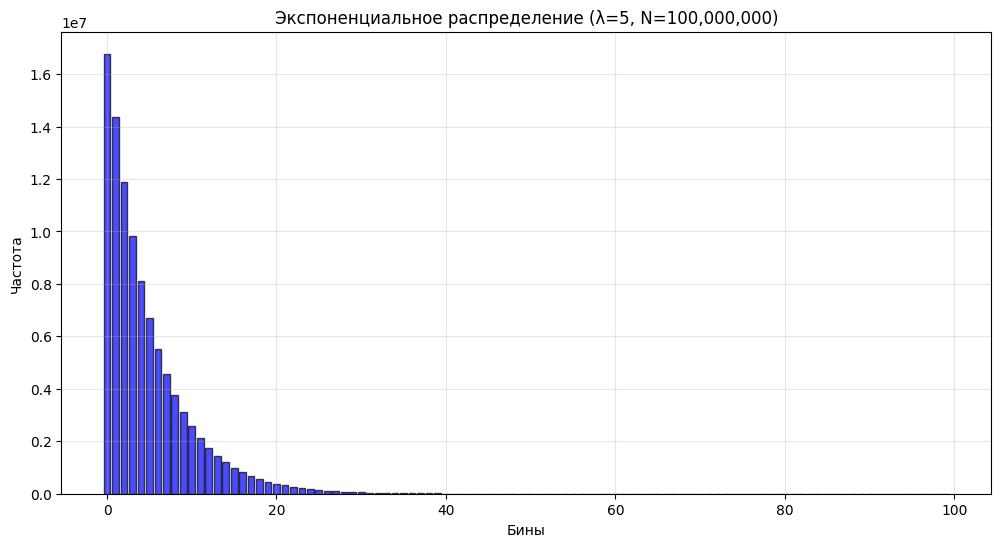

In [49]:
plt.figure(figsize=(12, 6))
plt.bar(range(bins), hist_cpu.numpy(), width=0.8, alpha=0.7, color='blue', edgecolor='black')
plt.title(f'Экспоненциальное распределение (λ={lambda_p}, N={N:,})')
plt.xlabel('Бины')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)
plt.show()

<p class="task" id="7"></p>

7\. Создайте четырехмерный тензор размера (10, 6, 6, 3), заполненный случайными целыми числами от 0 до 255. Считая, что данный тензор представляет собой батч из 10 картинок размера 6х6 в формате RGB, измените тензор следующим образом. Для оттенков красного обнулите все столбцы, кроме первых двух; для оттенков зеленого обнулите третий и четвертый столбцы; для оттенков синего обнулите пятый и шестой столбцы. Для выполнения задания используйте механизм распространения.

- [ ] Проверено на семинаре

In [60]:
p_sh7, z_sh7, y_sh7, x_sh7 = 10, 6, 6, 3 #размерность тензора (усл.)
x7 = torch.randint(0, 256, (p_sh7, z_sh7, y_sh7, x_sh7)) #заполнение числами 0-255

In [61]:
mask = torch.ones((1, 1, y_sh7, x_sh7), dtype=torch.int32) #маска на один слой (PxZ), в дальнейшем маска размножится
                                                           #на все столбцы и маски

In [62]:
mask[:, :, 2:, 0] = 0 #для красного все столбцы кроме первых двух обнуляются (нулевой канал строки - канал красного цвета)

mask[:, :, 2:4, 1] = 0 #для зеленого обнуляются 3 и 4 столбцы (первый канал строки - канал зеленого цвета)

mask[:, :, 4:6, 2] = 0 #для синего обнуляются 5 и 6 столбцы (второй канал строки - канал синего цвета)

In [66]:
res7 = x7 * mask #обнуление всех значений, где в маске стоят нулевые значения
res7.shape, mask[0, 0, :, :]

(torch.Size([10, 6, 6, 3]),
 tensor([[1, 1, 1],
         [1, 1, 1],
         [0, 0, 1],
         [0, 0, 1],
         [0, 1, 0],
         [0, 1, 0]], dtype=torch.int32))

In [67]:
res7

tensor([[[[ 85,  47, 220],
          [132, 133, 234],
          [  0,   0,  25],
          [  0,   0, 210],
          [  0,  57,   0],
          [  0,  46,   0]],

         [[152,  81, 191],
          [224, 108, 177],
          [  0,   0, 187],
          [  0,   0, 217],
          [  0, 178,   0],
          [  0, 164,   0]],

         [[204, 193, 244],
          [149, 199,  27],
          [  0,   0,  17],
          [  0,   0, 196],
          [  0,  37,   0],
          [  0, 217,   0]],

         [[103,  74, 101],
          [170, 224,  99],
          [  0,   0, 165],
          [  0,   0, 141],
          [  0,  63,   0],
          [  0, 226,   0]],

         [[235, 227,  36],
          [ 84, 141, 202],
          [  0,   0, 229],
          [  0,   0, 226],
          [  0, 119,   0],
          [  0, 140,   0]],

         [[ 67,  65,  88],
          [ 62, 128,  98],
          [  0,   0, 160],
          [  0,   0,  83],
          [  0,   9,   0],
          [  0,  43,   0]]],


        [[[154